In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

n = 500
klienci = ["Anna Kowalska", "  Jan Nowak", "Anna Kowalska", "PIOTR WIŚNIEWSKI",
           "katarzyna lewandowska", "Tomasz Zieliński ", "Marta Wójcik",
           "anna kowalska ", "Krzysztof Kamiński", " Magdalena Dąbrowska"]
produkty = ["Laptop", "Mysz", "Klawiatura", "Monitor", "laptop", "MYSZ",
            "Słuchawki", "Pendrive", "monitor", "Webcam"]
kategorie = ["Elektronika", "elektronika", "ELEKTRONIKA", "Akcesoria",
             "akcesoria", "Akcesoria "]
miasta = ["Warszawa", "Kraków", "warszawa", "Gdańsk", "WROCŁAW",
          "Poznań", "Łódź ", " Warszawa", "kraków"]

start_date = datetime(2025, 1, 1)
daty_iso = [(start_date + timedelta(days=int(d))).strftime("%Y-%m-%d")
            for d in np.random.randint(0, 300, n // 2)]
daty_pl = [(start_date + timedelta(days=int(d))).strftime("%d.%m.%Y")
           for d in np.random.randint(0, 300, n // 2)]
daty = daty_iso + daty_pl
np.random.shuffle(daty)

df = pd.DataFrame({
    "order_id": range(1001, 1001 + n),
    "klient": np.random.choice(klienci, n),
    "produkt": np.random.choice(produkty, n),
    "kategoria": np.random.choice(kategorie, n),
    "miasto": np.random.choice(miasta, n),
    "ilosc": np.random.choice([1, 2, 3, 5, -1, 0], n, p=[0.5, 0.2, 0.15, 0.1, 0.025, 0.025]),
    "cena_jednostkowa": np.random.choice(
        ["199.99", "299,99", "1 499.00", "89.50", "2999", "399.00 zł", None, "abc"],
        n
    ),
    "data_zamowienia": daty,
    "email": np.random.choice(
        ["anna@gmail.com", "JAN@WP.PL", "piotr.w@onet", "marta@gmail.com",
         "tomasz@interia.pl", None, "krzysztof.k@gmail.com", "brak"],
        n
    )
})

for col in ["miasto", "kategoria", "data_zamowienia"]:
    df.loc[df.sample(frac=0.05, random_state=1).index, col] = np.nan

df = pd.concat([df, df.sample(20, random_state=2)], ignore_index=True)

df.to_csv("zamowienia_messy.csv", index=False)
print(f"Wygenerowano plik 'zamowienia_messy.csv' — {len(df)} wierszy")

Wygenerowano plik 'zamowienia_messy.csv' — 520 wierszy


In [4]:
import pandas as pd
import numpy as np

# Wczytanie danych
df = pd.read_csv("zamowienia_messy.csv")

print("--- KROK 1: ROZMIAR ZBIORU ---")
print(df.shape)

print("\n--- KROK 2: STRUKTURA I TYPY ---")
print(df.info())

print("\n--- KROK 3: BRAKI W DANYCH ---")
print(df.isnull().sum())

print("\n--- KROK 4: STATYSTYKI WARTOŚCI LICZBOWYCH ---")
print(df.describe())

print("\n--- KROK 5: PRZYKŁADOWE WARTOŚCI UNIKALNE (KATEGORIE) ---")
print("Unikalne miasta:\n", df["miasto"].value_counts(dropna=False).head(5))
print("\nUnikalne kategorie:\n", df["kategoria"].value_counts(dropna=False).head(5))

--- KROK 1: ROZMIAR ZBIORU ---
(520, 9)

--- KROK 2: STRUKTURA I TYPY ---
<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   order_id          520 non-null    int64
 1   klient            520 non-null    str  
 2   produkt           520 non-null    str  
 3   kategoria         495 non-null    str  
 4   miasto            495 non-null    str  
 5   ilosc             520 non-null    int64
 6   cena_jednostkowa  457 non-null    str  
 7   data_zamowienia   495 non-null    str  
 8   email             457 non-null    str  
dtypes: int64(2), str(7)
memory usage: 36.7 KB
None

--- KROK 3: BRAKI W DANYCH ---
order_id             0
klient               0
produkt              0
kategoria           25
miasto              25
ilosc                0
cena_jednostkowa    63
data_zamowienia     25
email               63
dtype: int64

--- KROK 4: STATYSTYKI WARTOŚCI L

1. **Duplikaty wierszy:** Zbiór danych po wygenerowaniu ma 520 wierszy zamiast bazowych 500 (obecność jawnych duplikatów).
2. **Niespójność tekstowa (wielkość liter i białe znaki):** Nazwy miast (np. "Warszawa", "warszawa", " Warszawa") oraz klientów i kategorii są zapisane różną wielkością liter oraz zawierają zbędne spacje na początku/końcu.
3. **Błędne typy danych i formaty:** Kolumna `data_zamowienia` zawiera daty w dwóch formatach (ISO oraz polski format z kropkami) i jest traktowana jako tekst. Kolumna `cena_jednostkowa` zawiera tekst "zł", spacje jako separatory tysięcy, przecinki zamiast kropek oraz błędy typu "abc", przez co nie jest typem liczbowym.
4. **Wartości ujemne i zerowe w ilościach:** Kolumna `ilosc` zawiera wartości `-1` oraz `0`, co w kontekście zamówień e-commerce jest błędem logicznym.
5. **Brakujące wartości (NaN / null):** W kolumnach `miasto`, `kategoria`, `data_zamowienia`, `cena_jednostkowa` oraz `email` występują jawne braki danych (NaN) lub wartości tekstowe oznaczające brak (np. "brak").

In [5]:
# Usuwanie duplikatów
df = df.drop_duplicates()

# Standaryzacja kolumn tekstowych
df['klient'] = df['klient'].str.strip().str.title()
df['miasto'] = df['miasto'].str.strip().str.title()
df['produkt'] = df['produkt'].str.strip().str.title()
df['kategoria'] = df['kategoria'].str.strip().str.lower()


df['data_zamowienia'] = pd.to_datetime(df['data_zamowienia'], format='mixed', errors='coerce')

# Czyszczenie i konwersja ceny jednostkowej do float
df['cena_jednostkowa'] = (
    df['cena_jednostkowa']
    .astype(str)
    .str.replace(" zł", "", case=False)
    .str.replace(" ", "")
    .str.replace(",", ".")
)
df['cena_jednostkowa'] = pd.to_numeric(df['cena_jednostkowa'], errors='coerce')

# Usunięcie wierszy z kluczowymi brakami
df = df.dropna(subset=['cena_jednostkowa', 'data_zamowienia'])
# Wypełnienie pozostałych braków wartościami domyślnymi
df['miasto'] = df['miasto'].fillna('unknown')
df['kategoria'] = df['kategoria'].fillna('unknown')
df['email'] = df['email'].fillna('brak_emaila')

# Usunięcie zamówień o ilości <= 0
df = df[df['ilosc'] > 0]

print(f"Rozmiar zbioru po pełnym oczyszczeniu: {df.shape}")

Rozmiar zbioru po pełnym oczyszczeniu: (339, 9)


In [6]:
# Dodanie wartości zamówienia
df['wartosc_zamowienia'] = df['ilosc'] * df['cena_jednostkowa']

# Wyciąganie cech z daty
df['rok'] = df['data_zamowienia'].dt.year
df['miesiac'] = df['data_zamowienia'].dt.month
df['nazwa_dnia'] = df['data_zamowienia'].dt.day_name()

# Walidacja formatu e-mail za pomocą Regex (wzorzec: coś@coś.coś)
pattern = r'^[\w\.-]+@[\w\.-]+\.\w+$'
df['email_poprawny'] = df['email'].str.match(pattern, na=False)

# Wyświetlenie próbki danych po transformacji
df[['order_id', 'wartosc_zamowienia', 'rok', 'miesiac', 'nazwa_dnia', 'email_poprawny']].head()

,order_id,wartosc_zamowienia,rok,miesiac,nazwa_dnia,email_poprawny
0,1001,399.98,2025,6,Friday,False
1,1002,399.00,2025,4,Wednesday,True
4,1005,1499.00,2025,2,Wednesday,True
5,1006,299.99,2025,4,Monday,True
6,1007,1499.00,2025,10,Saturday,True


In [7]:
print("--- 1. Łączna wartość zamówień w każdym miesiącu ---")
miesieczna_wartosc = df.groupby('miesiac')['wartosc_zamowienia'].sum().round(2)
print(miesieczna_wartosc)

print("\n--- 2. Top 5 klientów pod względem łącznej wartości zamówień ---")
top_klienci = df.groupby('klient')['wartosc_zamowienia'].sum().nlargest(5).round(2)
print(top_klienci)

print("\n--- 3. Średnia wartość zamówienia w każdej kategorii ---")
srednia_kategoria = df.groupby('kategoria')['wartosc_zamowienia'].mean().round(2)
print(srednia_kategoria)

--- 1. Łączna wartość zamówień w każdym miesiącu ---
miesiac
1     36358.79
2     75622.72
3     64431.34
4     49546.74
5     36521.24
6     58297.78
7     46129.83
8     56420.22
9     69814.85
10    49199.25
11    12670.94
12     2576.98
Name: wartosc_zamowienia, dtype: float64

--- 2. Top 5 klientów pod względem łącznej wartości zamówień ---
klient
Anna Kowalska            203426.36
Krzysztof Kamiński        84677.82
Katarzyna Lewandowska     55083.04
Marta Wójcik              51070.25
Magdalena Dąbrowska       49000.33
Name: wartosc_zamowienia, dtype: float64

--- 3. Średnia wartość zamówienia w każdej kategorii ---
kategoria
akcesoria      1671.66
elektronika    1614.06
Name: wartosc_zamowienia, dtype: float64


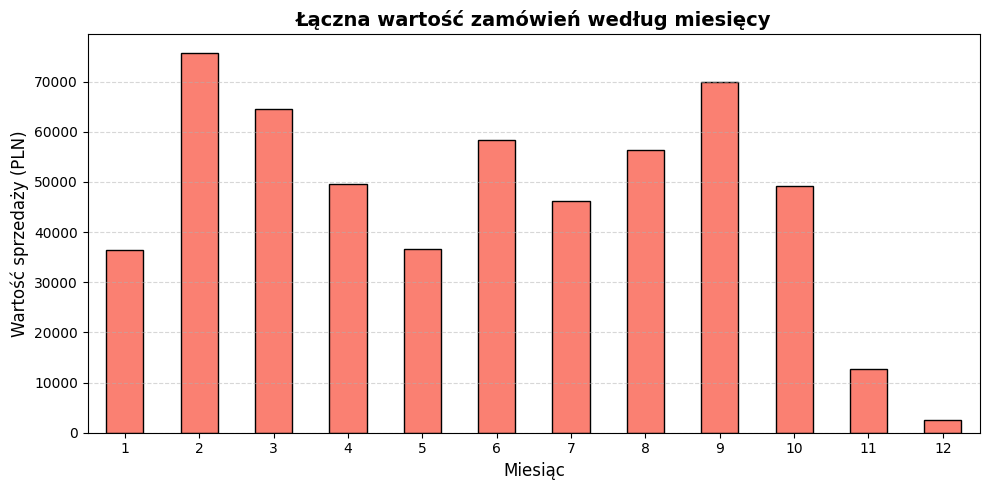

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
miesieczna_wartosc.plot(kind='bar', color='salmon', edgecolor='black')

plt.title('Łączna wartość zamówień według miesięcy', fontsize=14, fontweight='bold')
plt.xlabel('Miesiąc', fontsize=12)
plt.ylabel('Wartość sprzedaży (PLN)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
df.to_csv("zamowienia_clean.csv", index=False)
print("Plik 'zamowienia_clean.csv' został pomyślnie zapisany!")

Plik 'zamowienia_clean.csv' został pomyślnie zapisany!


In [10]:
df.to_csv("zamowienia_clean.csv", index=False)